# Database provisioning — docker-host n=5 initial analysis

Post-hoc analysis of the guarded `docker-host` n=5 pass across all six
agent/model extensions. Use this notebook to decide what to prune before a
larger scale run.

- Experiment: `database-provisioning-v2`
- Run request: `01KZVV5VG1XW5K7VQ7E75AAYTB`
- Matrix: 3 prompts × 6 extensions × `docker-host` × n=5 (90 trials)
- Date: 2026-08-12

This notebook queries AX with `ax experiment query <id> sql`. Re-run from the
metrics cell once the request finishes. Queries return derived metrics and
boolean evidence, not raw URIs or tool payloads.


Install analysis dependencies into the active kernel (the project `.venv` if that is selected). Then re-run the next cell.

`ax auth status` should show a signed-in org. Offline alternative: `ax run download 01KZVV5VG1XW5K7VQ7E75AAYTB`, then set `AX_PARQUET_DIR` to the resulting `.axp/downloads/<id>/` directory.


In [1]:
%pip install requests pandas matplotlib numpy python-dotenv

Note: you may need to restart the kernel to use updated packages.


In [2]:
from __future__ import annotations

import json
import os
import shutil
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from IPython.display import display

EXPERIMENT_ID = "database-provisioning-v2"
RUN_REQUEST_ID = "01KZVV5VG1XW5K7VQ7E75AAYTB"
EXPECTED_TRIALS = 90
AX_API_BASE = os.environ.get("AX_API_BASE", "https://app.514.ax").rstrip("/")
AX_PARQUET_DIR = os.environ.get("AX_PARQUET_DIR", "")
CLI_CREDENTIALS_PATH = Path.home() / ".fiveonefour/axp/credentials.toml"

DATABASE_ORDER = ["mongodb", "postgresql", "sqlite"]
EXTENSION_ORDER = [
    "claude-sonnet",
    "cursor-sonnet",
    "cursor-grok",
    "cursor-luna",
    "codex-luna",
    "codex-terra",
]
DISPLAY_NAMES = {
    "mongodb": "MongoDB",
    "postgresql": "PostgreSQL",
    "sqlite": "SQLite",
    "claude-sonnet": "Claude + Sonnet",
    "cursor-sonnet": "Cursor + Sonnet",
    "cursor-grok": "Cursor + Grok 4.5",
    "cursor-luna": "Cursor + Luna",
    "codex-luna": "Codex + Luna",
    "codex-terra": "Codex + Terra",
}
COLORS = {
    "mongodb": "#00A35C",
    "postgresql": "#336791",
    "sqlite": "#8C8C8C",
    "claude-sonnet": "#D97706",
    "cursor-sonnet": "#F59E0B",
    "cursor-grok": "#7C3AED",
    "cursor-luna": "#A78BFA",
    "codex-luna": "#374151",
    "codex-terra": "#111827",
}
EXTENSION_FROM_AGENT_MODEL = {
    ("claude", "claude-sonnet-5"): "claude-sonnet",
    ("cursor", "claude-sonnet-5"): "cursor-sonnet",
    ("cursor", "grok-4.5"): "cursor-grok",
    ("cursor", "gpt-5.6-luna"): "cursor-luna",
    ("codex", "gpt-5.6-luna"): "codex-luna",
    ("codex", "gpt-5.6-terra"): "codex-terra",
}
HARNESS_PAIRS = [
    ("claude-sonnet", "cursor-sonnet", "Sonnet across Claude vs Cursor"),
    ("codex-luna", "cursor-luna", "Luna across Codex vs Cursor"),
]

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 120)


def _load_dotenv() -> None:
    try:
        from dotenv import load_dotenv
    except ImportError:
        return
    here = Path.cwd().resolve()
    for directory in [here, *here.parents]:
        env_file = directory / ".env"
        if env_file.is_file():
            load_dotenv(env_file)
            return


def _credentials_from_cli_store() -> dict[str, str]:
    """Read key names from the AX CLI store. Never print values."""
    if not CLI_CREDENTIALS_PATH.is_file():
        return {}
    values: dict[str, str] = {}
    for line in CLI_CREDENTIALS_PATH.read_text().splitlines():
        stripped = line.strip()
        if not stripped or stripped.startswith("#") or stripped.startswith("["):
            continue
        if "=" not in stripped:
            continue
        key, value = stripped.split("=", 1)
        values[key.strip()] = value.strip().strip('"').strip("'")
    return values


_load_dotenv()
AX_ORG_ID = os.environ.get("AX_ORG_ID", "org_3FJv0fCt81VIGxO61n6HNbYLnHl")


def _api_key() -> str:
    key = os.environ.get("AX_API_KEY") or os.environ.get("AXP_API_KEY")
    if not key:
        key = _credentials_from_cli_store().get("api_key")
    if not key:
        raise RuntimeError(
            "No AX API key in AX_API_KEY / AXP_API_KEY, a repo .env, or "
            f"{CLI_CREDENTIALS_PATH}. Run `ax auth login` or create a token at "
            "https://app.514.ax/account/api-keys."
        )
    return key


def _parse_query_response(response: requests.Response) -> pd.DataFrame:
    text = response.text.strip()
    if not text:
        return pd.DataFrame()

    try:
        payload = response.json()
    except ValueError:
        rows = [json.loads(line) for line in text.splitlines() if line.strip()]
        return pd.DataFrame(rows)

    if isinstance(payload, list):
        return pd.DataFrame(payload)
    if isinstance(payload, dict):
        for key in ("rows", "data", "result", "results"):
            value = payload.get(key)
            if isinstance(value, list):
                return pd.DataFrame(value)
        if payload.get("sql") or payload.get("error"):
            raise RuntimeError(payload.get("error") or payload)
    raise RuntimeError(f"Unexpected AX query response shape: {type(payload).__name__}")


def ax_http_query(
    sql: str,
    *,
    experiment_id: str = EXPERIMENT_ID,
    run_id: str | None = None,
    limit: int = 10_000,
) -> pd.DataFrame:
    path = (
        f"/api/v1/runs/{run_id}/query"
        if run_id
        else f"/api/v1/experiments/{experiment_id}/query"
    )
    headers = {
        "Authorization": f"Bearer {_api_key()}",
        "Accept": "application/json",
        "Content-Type": "application/json",
    }
    if AX_ORG_ID:
        headers["X-Org-Id"] = AX_ORG_ID
    response = requests.post(
        f"{AX_API_BASE}{path}",
        headers=headers,
        json={"sql": sql, "limit": limit, "format": "json"},
        timeout=120,
    )
    if not response.ok:
        raise RuntimeError(
            f"AX query failed ({response.status_code}): {response.text[:500]}"
        )
    return _parse_query_response(response)


def ax_cli_query(sql: str, *, limit: int = 10_000) -> pd.DataFrame:
    ax = shutil.which("ax")
    if not ax:
        raise FileNotFoundError("ax CLI is not on PATH")
    command = [
        ax,
        "experiment",
        "query",
        EXPERIMENT_ID,
        "sql",
        sql,
        "--format",
        "json",
        "--limit",
        str(limit),
    ]
    if AX_ORG_ID:
        command.extend(["--org", AX_ORG_ID])
    result = subprocess.run(command, capture_output=True, text=True)
    if result.returncode != 0:
        raise RuntimeError(
            f"ax experiment query failed ({result.returncode}): {result.stderr.strip()[:500]}"
        )
    rows: list[dict] = []
    for line in result.stdout.splitlines():
        stripped = line.strip()
        if not stripped or stripped[0] not in "{[":
            continue
        try:
            parsed = json.loads(stripped)
        except json.JSONDecodeError:
            continue
        if isinstance(parsed, list):
            rows.extend(parsed)
        elif isinstance(parsed, dict):
            rows.append(parsed)
    return pd.DataFrame(rows)


def ax_parquet_query(sql: str) -> pd.DataFrame:
    try:
        import duckdb
    except ImportError as exc:
        raise RuntimeError("Install duckdb to query AX_PARQUET_DIR.") from exc

    root = Path(AX_PARQUET_DIR).expanduser()
    files = sorted(root.rglob("*.parquet"))
    if not files:
        raise FileNotFoundError(f"No parquet files under {root}")

    con = duckdb.connect()
    for path in files:
        con.execute(
            f"CREATE OR REPLACE VIEW {path.stem} AS SELECT * FROM read_parquet(?)",
            [str(path)],
        )
    return con.execute(sql).df()


def ax_query(sql: str, **kwargs) -> pd.DataFrame:
    if AX_PARQUET_DIR:
        return ax_parquet_query(sql)
    if shutil.which("ax"):
        return ax_cli_query(sql, limit=kwargs.get("limit", 10_000))
    return ax_http_query(sql, **kwargs)


def _with_database_column(frame: pd.DataFrame) -> pd.DataFrame:
    if "database" not in frame.columns and "prompt_id" in frame.columns:
        frame = frame.rename(columns={"prompt_id": "database"})
    return frame


def assign_extension(frame: pd.DataFrame) -> pd.DataFrame:
    if frame.empty:
        frame["extension"] = pd.Series(dtype="object")
        return frame
    if "resolved_extend_id" in frame.columns:
        mapped = frame["resolved_extend_id"].fillna("").replace("", np.nan)
    else:
        mapped = pd.Series(np.nan, index=frame.index)
    fallback = [
        EXTENSION_FROM_AGENT_MODEL.get((agent, model), f"{agent}+{model}")
        for agent, model in zip(frame.get("agent", []), frame.get("model", []))
    ]
    frame = frame.copy()
    frame["extension"] = mapped.fillna(pd.Series(fallback, index=frame.index))
    known = [name for name in EXTENSION_ORDER if name in set(frame["extension"])]
    extra = sorted(set(frame["extension"]) - set(EXTENSION_ORDER))
    frame["extension"] = pd.Categorical(
        frame["extension"], categories=known + extra, ordered=True
    )
    return frame


def wilson_interval(successes: float, n: float, z: float = 1.96) -> tuple[float, float, float]:
    if n <= 0:
        return (np.nan, np.nan, np.nan)
    p = successes / n
    z2 = z * z
    denom = 1 + z2 / n
    center = (p + z2 / (2 * n)) / denom
    margin = z * np.sqrt((p * (1 - p) + z2 / (4 * n)) / n) / denom
    return p, max(0.0, center - margin), min(1.0, center + margin)


print(f"Experiment: {EXPERIMENT_ID}")
print(f"Run request: {RUN_REQUEST_ID}")
print(f"Expected trials: {EXPECTED_TRIALS}")
print(f"ax CLI: {shutil.which('ax') or 'not on PATH'}")
print(
    "Query surface: "
    + (
        f"parquet {AX_PARQUET_DIR}"
        if AX_PARQUET_DIR
        else "ax experiment query CLI"
        if shutil.which("ax")
        else f"{AX_API_BASE}/api/v1/experiments/{EXPERIMENT_ID}/query"
    )
)


Experiment: database-provisioning-v2
Run request: 01KZVV5VG1XW5K7VQ7E75AAYTB
Expected trials: 90
ax CLI: /opt/homebrew/bin/ax
Query surface: ax experiment query CLI


## Per-run metrics

Official AX `measurements` for this run request. `tool_calls_total` is the step
proxy. A run **passes** only when both `uri-reported` and
`connection-verified-in-agent` succeed.

If this cell prints fewer than 90 rows, the request is still running or some
trials starved. Re-run from here when `ax run view 01KZVV5VG1XW5K7VQ7E75AAYTB`
is terminal.


In [3]:
per_run_sql = f"""
SELECT
    run_id,
    agent,
    model,
    resolved_extend_id,
    prompt_id,
    repeat_idx,
    status,
    exit_reason,
    test_pass_count,
    test_fail_count,
    agent_time_ms / 1000.0 AS runtime_s,
    num_turns,
    tool_calls_total,
    tool_calls_failed,
    input_tokens,
    output_tokens,
    cost_usd_micros / 1000000.0 AS cost_usd
FROM measurements
WHERE run_request_id = '{RUN_REQUEST_ID}'
ORDER BY agent, model, prompt_id, repeat_idx
"""

runs = assign_extension(_with_database_column(ax_query(per_run_sql)))
READY = not runs.empty
if not READY:
    print(
        f"No measurements yet for {RUN_REQUEST_ID}. "
        "The notebook is set up; re-run from this cell when the request finishes."
    )
else:
    numeric_columns = [
        "repeat_idx",
        "test_pass_count",
        "test_fail_count",
        "runtime_s",
        "num_turns",
        "tool_calls_total",
        "tool_calls_failed",
        "input_tokens",
        "output_tokens",
        "cost_usd",
    ]
    present = [column for column in numeric_columns if column in runs.columns]
    runs[present] = runs[present].apply(pd.to_numeric)
    runs["both_tests_passed"] = runs["status"].eq("pass")
    runs["database"] = pd.Categorical(runs["database"], categories=DATABASE_ORDER, ordered=True)
    print(
        f"Finished measurement rows: {len(runs)} "
        f"(expected {EXPECTED_TRIALS} if none starved)"
    )
    display(runs.head())


Finished measurement rows: 88 (expected 90 if none starved)


,run_id,agent,model,resolved_extend_id,database,repeat_idx,status,exit_reason,test_pass_count,test_fail_count,runtime_s,num_turns,tool_calls_total,tool_calls_failed,input_tokens,output_tokens,cost_usd,extension,both_tests_passed
0,claude::anthropic-claude-sonnet-5::mongodb::docker-host::claude-sonnet::e86de722792d3d71,claude,claude-sonnet-5,claude-sonnet,mongodb,0,pass,end_turn,2,0,57.960,8,7,1,15,1816,0.185214,claude-sonnet,True
1,claude::anthropic-claude-sonnet-5::mongodb::docker-host::claude-sonnet::cac17681fb348f6b,claude,claude-sonnet-5,claude-sonnet,mongodb,1,pass,end_turn,2,0,62.835,8,7,1,15,1521,0.191984,claude-sonnet,True
2,claude::anthropic-claude-sonnet-5::mongodb::docker-host::claude-sonnet::c37be3389b62ac26,claude,claude-sonnet-5,claude-sonnet,mongodb,2,pass,end_turn,2,0,49.732,7,6,1,13,1148,0.336467,claude-sonnet,True
3,claude::anthropic-claude-sonnet-5::mongodb::docker-host::claude-sonnet::ca83b24452b785f5,claude,claude-sonnet-5,claude-sonnet,mongodb,3,pass,end_turn,2,0,56.639,8,7,1,15,1719,0.194935,claude-sonnet,True
4,claude::anthropic-claude-sonnet-5::mongodb::docker-host::claude-sonnet::2ac0c0c45780de43,claude,claude-sonnet-5,claude-sonnet,mongodb,4,pass,end_turn,2,0,65.343,9,8,1,17,2155,0.402203,claude-sonnet,True


## Official test outcomes


In [4]:
if not READY:
    tests = pd.DataFrame()
    failures = pd.DataFrame()
    print("Waiting for measurements.")
else:
    tests_sql = f"""
    SELECT
        agent,
        model,
        resolved_extend_id,
        prompt_id,
        repeat_idx,
        test_name,
        exit_code = 0 AS passed,
        exit_code
    FROM test_output
    WHERE run_request_id = '{RUN_REQUEST_ID}'
    ORDER BY agent, model, prompt_id, repeat_idx, test_name
    """
    tests = assign_extension(_with_database_column(ax_query(tests_sql)))
    tests["repeat_idx"] = pd.to_numeric(tests["repeat_idx"])
    tests["exit_code"] = pd.to_numeric(tests["exit_code"])
    tests["passed"] = tests["passed"].astype(bool)
    tests["database"] = pd.Categorical(tests["database"], categories=DATABASE_ORDER, ordered=True)

    test_summary = (
        tests.groupby(["extension", "database", "test_name"], observed=True)["passed"]
        .agg(passes="sum", n="count", rate="mean")
        .reset_index()
    )
    test_summary["rate_pct"] = test_summary["rate"] * 100
    display(test_summary)

    failures_sql = f"""
    SELECT
        agent,
        model,
        resolved_extend_id,
        prompt_id,
        repeat_idx,
        test_name,
        exit_code,
        stderr_tail
    FROM test_output
    WHERE run_request_id = '{RUN_REQUEST_ID}'
      AND exit_code != 0
    ORDER BY agent, model, prompt_id, repeat_idx, test_name
    """
    failures = assign_extension(_with_database_column(ax_query(failures_sql)))
    if failures.empty:
        print("No test failures on finished runs.")
    else:
        display(failures)


,extension,database,test_name,passes,n,rate,rate_pct
0,claude-sonnet,mongodb,connection-verified-in-agent,5,5,1.0,100.0
1,claude-sonnet,mongodb,uri-reported,5,5,1.0,100.0
2,claude-sonnet,postgresql,connection-verified-in-agent,4,5,0.8,80.0
3,claude-sonnet,postgresql,uri-reported,5,5,1.0,100.0
4,claude-sonnet,sqlite,connection-verified-in-agent,5,5,1.0,100.0
5,claude-sonnet,sqlite,uri-reported,5,5,1.0,100.0
6,cursor-sonnet,mongodb,connection-verified-in-agent,5,5,1.0,100.0
7,cursor-sonnet,mongodb,uri-reported,5,5,1.0,100.0
8,cursor-sonnet,postgresql,connection-verified-in-agent,5,5,1.0,100.0
9,cursor-sonnet,postgresql,uri-reported,5,5,1.0,100.0


,agent,model,resolved_extend_id,database,repeat_idx,test_name,exit_code,stderr_tail,extension
0,claude,claude-sonnet-5,claude-sonnet,postgresql,4,connection-verified-in-agent,1,24 rows · 130 ms\nOnly readiness/TCP evidence was found for postgresql; an application-level operation is required\n,claude-sonnet
1,cursor,claude-sonnet-5,cursor-sonnet,sqlite,3,uri-reported,1,26 rows · 67 ms\n,cursor-sonnet
2,cursor,gpt-5.6-luna,cursor-luna,postgresql,0,connection-verified-in-agent,1,22 rows · 95 ms\nOnly readiness/TCP evidence was found for postgresql; an application-level operation is required\n,cursor-luna
3,cursor,grok-4.5,cursor-grok,postgresql,3,connection-verified-in-agent,1,8 rows · 200 ms\nOnly readiness/TCP evidence was found for postgresql; an application-level operation is required\n,cursor-grok


## Summary by extension and database


In [5]:
if not READY:
    summary = pd.DataFrame()
    print("Waiting for measurements.")
else:
    summary = (
        runs.groupby(["extension", "database"], observed=True)
        .agg(
            runs=("run_id", "size"),
            both_tests_passed=("both_tests_passed", "sum"),
            pass_rate=("both_tests_passed", "mean"),
            runtime_mean_s=("runtime_s", "mean"),
            turns_mean=("num_turns", "mean"),
            tool_calls_mean=("tool_calls_total", "mean"),
            cost_total_usd=("cost_usd", "sum"),
            cost_mean_usd=("cost_usd", "mean"),
        )
        .reset_index()
    )
    intervals = [
        wilson_interval(row.both_tests_passed, row.runs)
        for row in summary.itertuples()
    ]
    summary["pass_rate"] = [item[0] for item in intervals]
    summary["pass_rate_lo"] = [item[1] for item in intervals]
    summary["pass_rate_hi"] = [item[2] for item in intervals]
    summary["pass_rate_pct"] = summary["pass_rate"] * 100
    summary["extension_label"] = summary["extension"].map(DISPLAY_NAMES).fillna(summary["extension"].astype(str))
    summary["database_label"] = summary["database"].map(DISPLAY_NAMES)

    totals = pd.Series(
        {
            "finished_runs": len(runs),
            "expected_trials": EXPECTED_TRIALS,
            "run_passes": int(runs["both_tests_passed"].sum()),
            "tests_passed": int(runs["test_pass_count"].sum()),
            "tests_failed": int(runs["test_fail_count"].sum()),
            "total_cost_usd": float(runs["cost_usd"].sum()),
            "mean_cost_usd": float(runs["cost_usd"].mean()),
            "mean_runtime_s": float(runs["runtime_s"].mean()),
            "mean_turns": float(runs["num_turns"].mean()),
            "mean_tool_calls": float(runs["tool_calls_total"].mean()),
        }
    )
    display(totals.to_frame("value").round(3))
    display(
        summary[
            [
                "extension_label",
                "database_label",
                "runs",
                "both_tests_passed",
                "pass_rate_pct",
                "pass_rate_lo",
                "pass_rate_hi",
                "runtime_mean_s",
                "turns_mean",
                "tool_calls_mean",
                "cost_mean_usd",
                "cost_total_usd",
            ]
        ].round(3)
    )


,value
finished_runs,88.000
expected_trials,90.000
run_passes,84.000
tests_passed,172.000
tests_failed,4.000
total_cost_usd,11.746
mean_cost_usd,0.133
mean_runtime_s,48.795
mean_turns,3.148
mean_tool_calls,6.250


,extension_label,database_label,runs,both_tests_passed,pass_rate_pct,pass_rate_lo,pass_rate_hi,runtime_mean_s,turns_mean,tool_calls_mean,cost_mean_usd,cost_total_usd
0,Claude + Sonnet,MongoDB,5,5,100.0,0.566,1.000,58.502,8.0,7.000,0.262,1.311
1,Claude + Sonnet,PostgreSQL,5,4,80.0,0.376,0.964,51.260,8.4,7.400,0.182,0.911
2,Claude + Sonnet,SQLite,5,5,100.0,0.566,1.000,41.135,5.0,4.000,0.219,1.095
3,Cursor + Sonnet,MongoDB,5,5,100.0,0.566,1.000,54.776,3.6,5.600,0.174,0.872
4,Cursor + Sonnet,PostgreSQL,5,5,100.0,0.566,1.000,57.488,3.6,7.200,0.216,1.082
5,Cursor + Sonnet,SQLite,5,4,80.0,0.376,0.964,92.257,4.4,9.400,0.295,1.474
6,Cursor + Grok 4.5,MongoDB,5,5,100.0,0.566,1.000,43.841,4.0,4.200,0.145,0.725
7,Cursor + Grok 4.5,PostgreSQL,5,4,80.0,0.376,0.964,36.012,4.0,3.800,0.136,0.681
8,Cursor + Grok 4.5,SQLite,5,5,100.0,0.566,1.000,41.397,2.8,4.200,0.177,0.887
9,Cursor + Luna,MongoDB,5,5,100.0,0.566,1.000,77.377,2.4,8.200,0.079,0.396


## Visualize pass rate, runtime, and cost


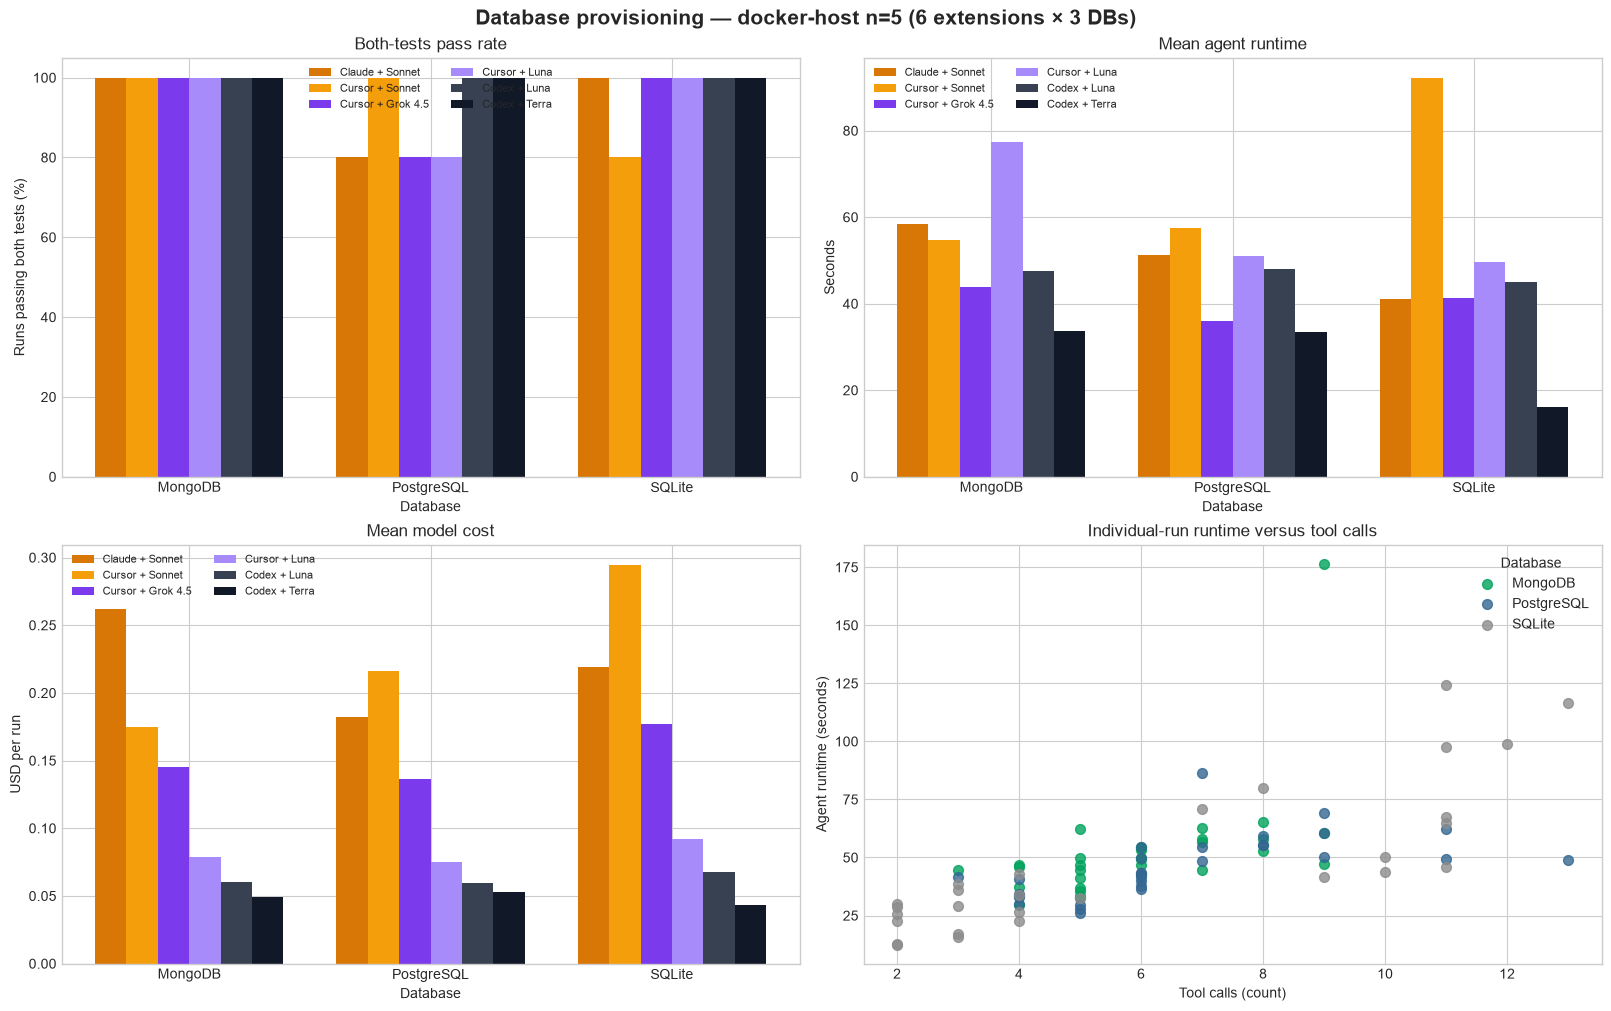

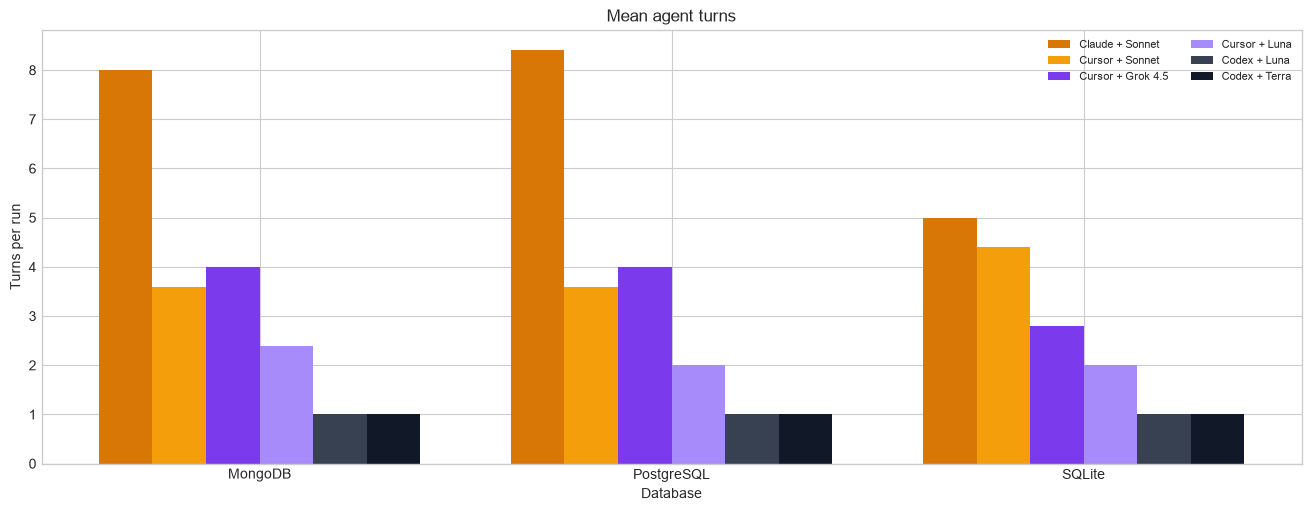

In [6]:
if not READY or summary.empty:
    print("Waiting for measurements.")
else:
    extensions = [name for name in EXTENSION_ORDER if name in set(summary["extension"])]
    fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)
    fig.suptitle(
        "Database provisioning — docker-host n=5 (6 extensions × 3 DBs)",
        fontsize=15,
        fontweight="bold",
    )
    x = np.arange(len(DATABASE_ORDER))
    width = 0.13

    def grouped_bars(ax, column, title, ylabel, percent=False):
        for index, extension in enumerate(extensions):
            subset = (
                summary[summary["extension"] == extension]
                .set_index("database")
                .reindex(DATABASE_ORDER)
            )
            ax.bar(
                x + (index - (len(extensions) - 1) / 2) * width,
                subset[column].fillna(0),
                width=width,
                label=DISPLAY_NAMES.get(extension, extension),
                color=COLORS.get(extension, "#6B7280"),
            )
        ax.set_title(title)
        ax.set_xlabel("Database")
        ax.set_ylabel(ylabel)
        ax.set_xticks(x, [DISPLAY_NAMES[name] for name in DATABASE_ORDER])
        if percent:
            ax.set_ylim(0, 105)
        ax.legend(frameon=False, fontsize=8, ncol=2)

    grouped_bars(axes[0, 0], "pass_rate_pct", "Both-tests pass rate", "Runs passing both tests (%)", percent=True)
    grouped_bars(axes[0, 1], "runtime_mean_s", "Mean agent runtime", "Seconds")
    grouped_bars(axes[1, 0], "cost_mean_usd", "Mean model cost", "USD per run")

    for database in DATABASE_ORDER:
        subset = runs[runs["database"] == database]
        axes[1, 1].scatter(
            subset["tool_calls_total"],
            subset["runtime_s"],
            label=DISPLAY_NAMES[database],
            color=COLORS[database],
            s=50,
            alpha=0.8,
        )
    axes[1, 1].set_title("Individual-run runtime versus tool calls")
    axes[1, 1].set_xlabel("Tool calls (count)")
    axes[1, 1].set_ylabel("Agent runtime (seconds)")
    axes[1, 1].legend(title="Database", frameon=False)
    plt.show()

    fig, ax = plt.subplots(figsize=(13, 5), constrained_layout=True)
    grouped_bars(ax, "turns_mean", "Mean agent turns", "Turns per run")
    plt.show()


## Provisioning methods: attempted paths and inferred final method

Classify method evidence from ordered agent tool calls using the repository's
provisioning-method codebook. The query returns only method sequence numbers—not
commands, payloads, URIs, or credentials.

- **Attempted methods** count every acquisition/runtime path the agent executed.
  One run can contribute to multiple methods after fallback.
- **Inferred final method** is the latest method-specific provisioning action on
  runs that passed both tests. Failed runs are `none/unverified`.

This is a heuristic classification. `apt` followed by `docker run` is counted as
both attempted methods with `container` final. Standard-library Python
`sqlite3` is `built-in-library`, not an installation.

,extension,database,repeat_idx,attempted_path,final_method,both_tests_passed
0,claude-sonnet,mongodb,0,container,container,True
1,claude-sonnet,mongodb,1,container,container,True
2,claude-sonnet,mongodb,2,container,container,True
3,claude-sonnet,mongodb,3,container,container,True
4,claude-sonnet,mongodb,4,container,container,True
...,...,...,...,...,...,...
40,codex-terra,sqlite,0,built-in-library,built-in-library,True
41,codex-terra,sqlite,1,built-in-library,built-in-library,True
42,codex-terra,sqlite,2,built-in-library,built-in-library,True
43,codex-terra,sqlite,3,built-in-library,built-in-library,True


Attempted method counts (a fallback run may appear more than once):


,database,attempted_methods,runs
0,mongodb,container,30
1,postgresql,container,30
2,postgresql,os-package-manager,1
3,sqlite,built-in-library,23
4,sqlite,container,4
5,sqlite,language-package-runtime,1
6,sqlite,os-package-manager,1
7,sqlite,preinstalled-runtime,1


Inferred final method counts:


,database,final_method,runs
0,mongodb,container,30
1,postgresql,container,26
2,postgresql,none/unverified,3
3,postgresql,os-package-manager,1
4,sqlite,built-in-library,21
5,sqlite,container,4
6,sqlite,language-package-runtime,1
7,sqlite,none/unverified,1
8,sqlite,preinstalled-runtime,1


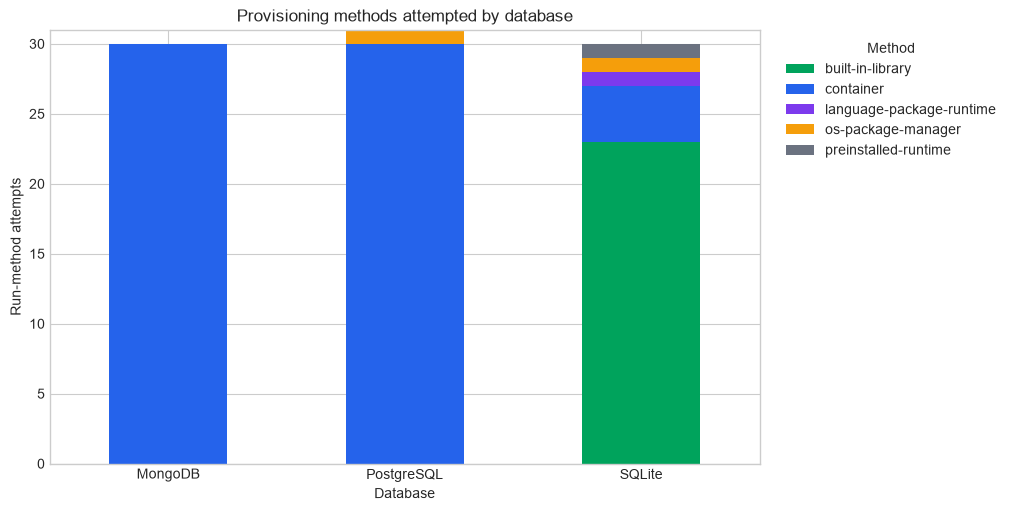

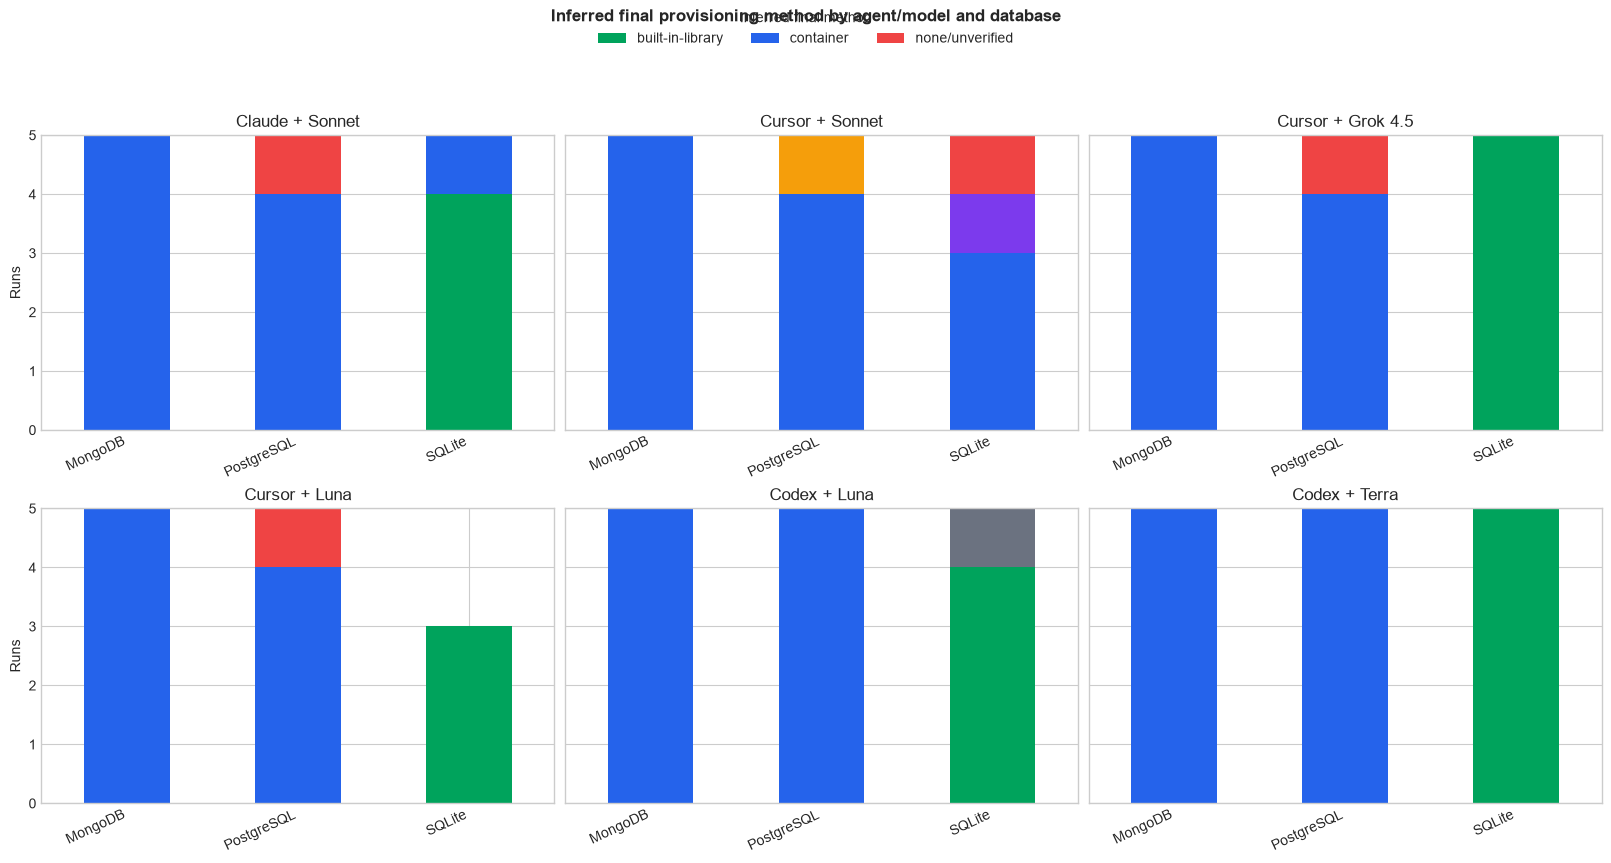

In [7]:
if not READY:
    method_runs = pd.DataFrame()
    print("Waiting for measurements.")
else:
    method_sql = f"""
    SELECT
        run_id,
        maxIf(toUInt64(coalesce(source_seq, 0)),
            positionCaseInsensitive(payload, 'docker run') > 0
            OR positionCaseInsensitive(payload, 'podman run') > 0
        ) AS container_seq,
        maxIf(toUInt64(coalesce(source_seq, 0)),
            (
                positionCaseInsensitive(payload, 'apt-get install') > 0
                OR positionCaseInsensitive(payload, 'apt install') > 0
                OR positionCaseInsensitive(payload, 'dnf install') > 0
                OR positionCaseInsensitive(payload, 'yum install') > 0
                OR positionCaseInsensitive(payload, 'apk add') > 0
                OR positionCaseInsensitive(payload, 'brew install') > 0
            )
            AND positionCaseInsensitive(payload, 'docker') = 0
            AND (
                (prompt_id = 'mongodb' AND positionCaseInsensitive(payload, 'mongo') > 0)
                OR (prompt_id = 'postgresql' AND positionCaseInsensitive(payload, 'postgres') > 0)
                OR (prompt_id = 'sqlite' AND positionCaseInsensitive(payload, 'sqlite') > 0)
            )
        ) AS os_package_manager_seq,
        maxIf(toUInt64(coalesce(source_seq, 0)),
            (
                positionCaseInsensitive(payload, 'curl ') > 0
                OR positionCaseInsensitive(payload, 'wget ') > 0
            )
            AND (
                positionCaseInsensitive(payload, '.tgz') > 0
                OR positionCaseInsensitive(payload, '.tar.gz') > 0
                OR positionCaseInsensitive(payload, '.zip') > 0
            )
            AND (
                (prompt_id = 'mongodb' AND positionCaseInsensitive(payload, 'mongo') > 0)
                OR (prompt_id = 'postgresql' AND positionCaseInsensitive(payload, 'postgres') > 0)
                OR (prompt_id = 'sqlite' AND positionCaseInsensitive(payload, 'sqlite') > 0)
            )
        ) AS official_binary_archive_seq,
        maxIf(toUInt64(coalesce(source_seq, 0)),
            (
                positionCaseInsensitive(payload, 'pip install') > 0
                OR positionCaseInsensitive(payload, 'pip3 install') > 0
                OR positionCaseInsensitive(payload, 'npm install') > 0
                OR positionCaseInsensitive(payload, 'npm add') > 0
            )
            AND (
                (prompt_id = 'mongodb' AND positionCaseInsensitive(payload, 'mongo') > 0)
                OR (prompt_id = 'postgresql' AND positionCaseInsensitive(payload, 'postgres') > 0)
                OR (prompt_id = 'sqlite' AND (
                    positionCaseInsensitive(payload, 'sqlite') > 0
                    OR positionCaseInsensitive(payload, 'libsql') > 0
                    OR positionCaseInsensitive(payload, 'sqld') > 0
                ))
            )
        ) AS language_package_runtime_seq,
        maxIf(toUInt64(coalesce(source_seq, 0)),
            prompt_id = 'sqlite'
            AND (
                positionCaseInsensitive(payload, 'import sqlite3') > 0
                OR positionCaseInsensitive(payload, 'from sqlite3') > 0
            )
        ) AS built_in_library_seq,
        maxIf(toUInt64(coalesce(source_seq, 0)),
            (
                (prompt_id = 'mongodb' AND (
                    positionCaseInsensitive(payload, ' mongod ') > 0
                    OR positionCaseInsensitive(payload, 'systemctl start mongod') > 0
                ))
                OR (prompt_id = 'postgresql' AND (
                    positionCaseInsensitive(payload, 'pg_ctl') > 0
                    OR positionCaseInsensitive(payload, 'systemctl start postgres') > 0
                ))
                OR (prompt_id = 'sqlite' AND positionCaseInsensitive(payload, 'sqlite3 ') > 0)
            )
        ) AS preinstalled_runtime_seq
    FROM events
    WHERE run_request_id = '{RUN_REQUEST_ID}'
      AND kind = 'tool_call'
      AND coalesce(assertion_role, 'primary') = 'primary'
    GROUP BY run_id
    """
    method_evidence = ax_query(method_sql)
    sequence_columns = {
        "container": "container_seq",
        "os-package-manager": "os_package_manager_seq",
        "official-binary-archive": "official_binary_archive_seq",
        "language-package-runtime": "language_package_runtime_seq",
        "built-in-library": "built_in_library_seq",
        "preinstalled-runtime": "preinstalled_runtime_seq",
    }
    for column in sequence_columns.values():
        method_evidence[column] = pd.to_numeric(method_evidence[column]).fillna(0)

    method_runs = runs.merge(method_evidence, on="run_id", how="left")

    def classify_methods(row):
        ordered = [
            (method, int(row.get(column, 0) or 0))
            for method, column in sequence_columns.items()
            if int(row.get(column, 0) or 0) > 0
        ]
        acquisition_methods = {
            "container",
            "os-package-manager",
            "official-binary-archive",
            "language-package-runtime",
            "built-in-library",
        }
        # Starting software installed by apt/npm is part of that install path,
        # not a separate preinstalled-runtime method.
        if any(method in acquisition_methods for method, _ in ordered):
            ordered = [item for item in ordered if item[0] != "preinstalled-runtime"]
        ordered.sort(key=lambda item: item[1])
        attempted = [method for method, _ in ordered] or ["unknown"]
        final = attempted[-1] if bool(row["both_tests_passed"]) else "none/unverified"
        return attempted, final

    classified = method_runs.apply(classify_methods, axis=1)
    method_runs["attempted_methods"] = [item[0] for item in classified]
    method_runs["final_method"] = [item[1] for item in classified]
    method_runs["attempted_path"] = method_runs["attempted_methods"].str.join(" → ")

    method_display = method_runs[
        ["extension", "database", "repeat_idx", "attempted_path", "final_method", "both_tests_passed"]
    ].sort_values(["database", "extension", "repeat_idx"])
    display(method_display)

    attempted = method_runs[["run_id", "database", "extension", "attempted_methods"]].explode("attempted_methods")
    attempted_counts = (
        attempted.groupby(["database", "attempted_methods"], observed=True)
        .size()
        .rename("runs")
        .reset_index()
    )
    final_counts = (
        method_runs.groupby(["database", "final_method"], observed=True)
        .size()
        .rename("runs")
        .reset_index()
    )
    print("Attempted method counts (a fallback run may appear more than once):")
    display(attempted_counts)
    print("Inferred final method counts:")
    display(final_counts)

    method_colors = {
        "container": "#2563EB",
        "os-package-manager": "#F59E0B",
        "official-binary-archive": "#DC2626",
        "language-package-runtime": "#7C3AED",
        "built-in-library": "#00A35C",
        "preinstalled-runtime": "#6B7280",
        "unknown": "#D1D5DB",
        "none/unverified": "#EF4444",
    }

    attempted_pivot = attempted_counts.pivot(
        index="database", columns="attempted_methods", values="runs"
    ).fillna(0).reindex(DATABASE_ORDER)
    fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
    attempted_pivot.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=[method_colors.get(column, "#9CA3AF") for column in attempted_pivot.columns],
    )
    ax.set_title("Provisioning methods attempted by database")
    ax.set_xlabel("Database")
    ax.set_ylabel("Run-method attempts")
    ax.set_xticklabels([DISPLAY_NAMES[name] for name in DATABASE_ORDER], rotation=0)
    ax.legend(title="Method", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.show()

    present_extensions = [name for name in EXTENSION_ORDER if name in set(method_runs["extension"])]
    fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharey=True, constrained_layout=True)
    for ax, extension in zip(axes.flat, present_extensions):
        subset = method_runs[method_runs["extension"] == extension]
        pivot = pd.crosstab(subset["database"], subset["final_method"]).reindex(DATABASE_ORDER, fill_value=0)
        pivot.plot(
            kind="bar",
            stacked=True,
            ax=ax,
            color=[method_colors.get(column, "#9CA3AF") for column in pivot.columns],
            legend=False,
        )
        ax.set_title(DISPLAY_NAMES.get(extension, extension))
        ax.set_xlabel("")
        ax.set_ylabel("Runs")
        ax.set_xticklabels([DISPLAY_NAMES[name] for name in DATABASE_ORDER], rotation=25, ha="right")
    handles, labels = axes.flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, title="Inferred final method", loc="outside upper center", ncol=4, frameon=False)
    fig.suptitle("Inferred final provisioning method by agent/model and database", y=1.06, fontweight="bold")
    plt.show()

## Efficiency views when completion is near ceiling

The Pareto frontier is not informative when nearly every cell has 80–100%
completion. Replace it with three direct efficiency views:

1. **Cost dot-and-whisker:** every measured run, median, and interquartile range;
   failed runs are red `×` markers rather than silently excluded.
2. **Runtime distribution:** horizontal boxplots plus every measured run.
3. **Efficiency rank heatmaps:** separate within-database ranks for runtime,
   cost, and turns. Keeping these metrics separate avoids an arbitrary composite
   score. Rank 1 is most efficient.

The two starved Cursor+Luna/SQLite runs have no measurement rows, so that cell
shows only n=3. Reliability remains reported separately from efficiency.

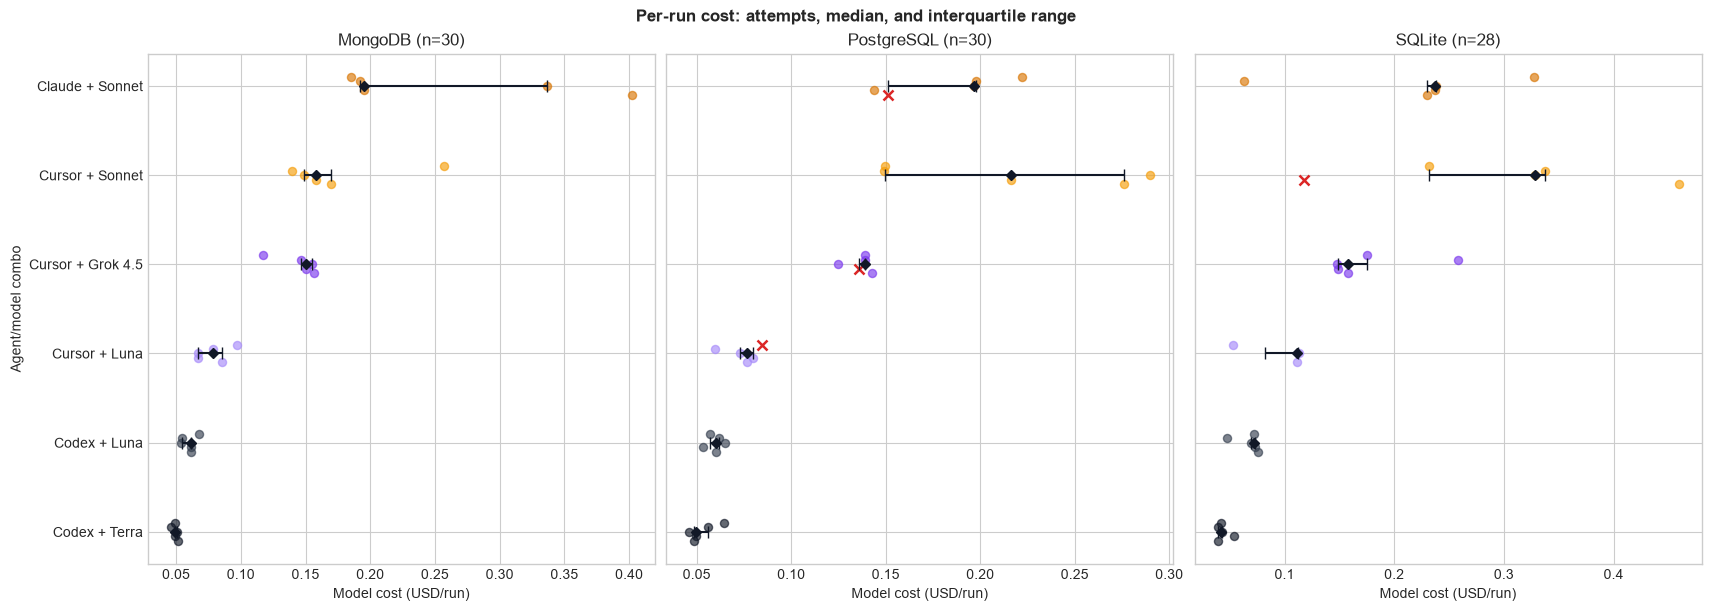

/var/folders/k_/t69hh4cj3yg5kjzv52_x6_6r0000gp/T/ipykernel_40252/4275927635.py:83: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  boxes = ax.boxplot(
/var/folders/k_/t69hh4cj3yg5kjzv52_x6_6r0000gp/T/ipykernel_40252/4275927635.py:83: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  boxes = ax.boxplot(
/var/folders/k_/t69hh4cj3yg5kjzv52_x6_6r0000gp/T/ipykernel_40252/4275927635.py:83: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  boxes = ax.boxplot(


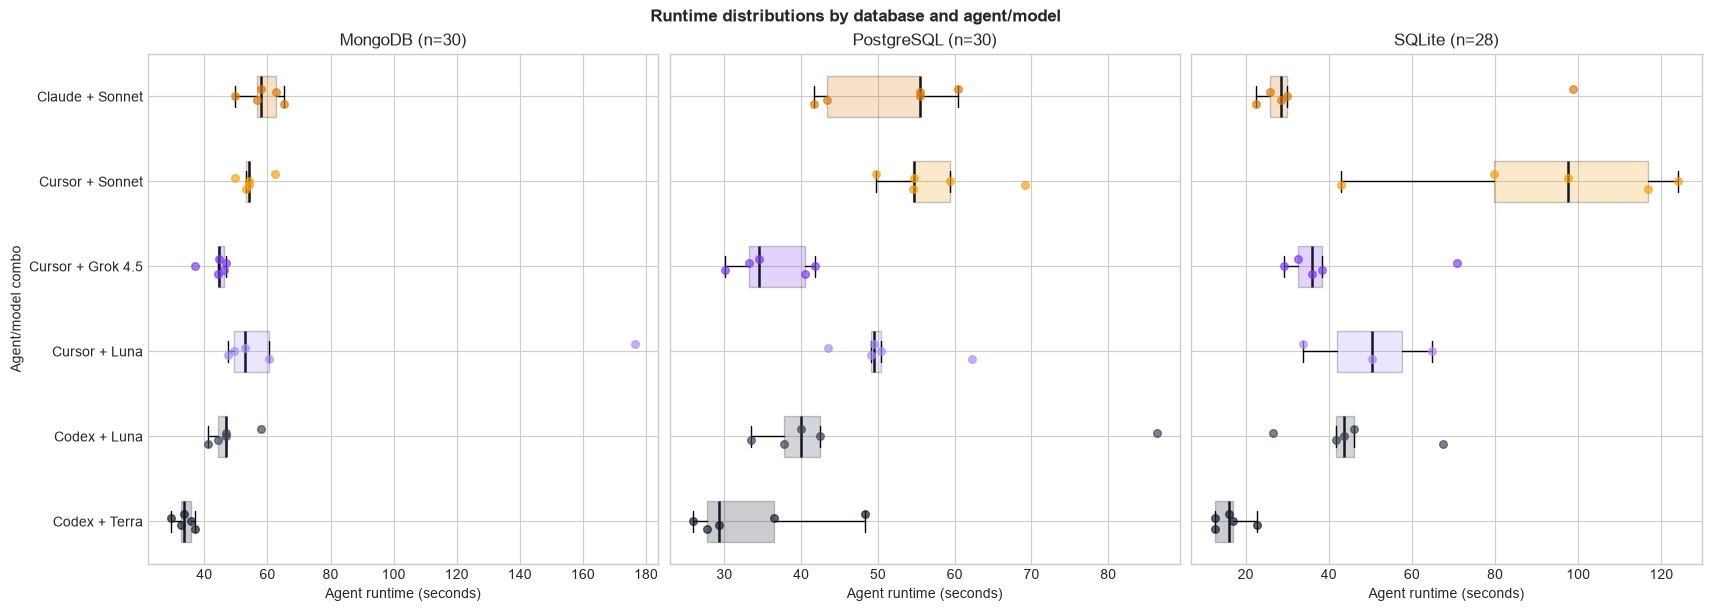

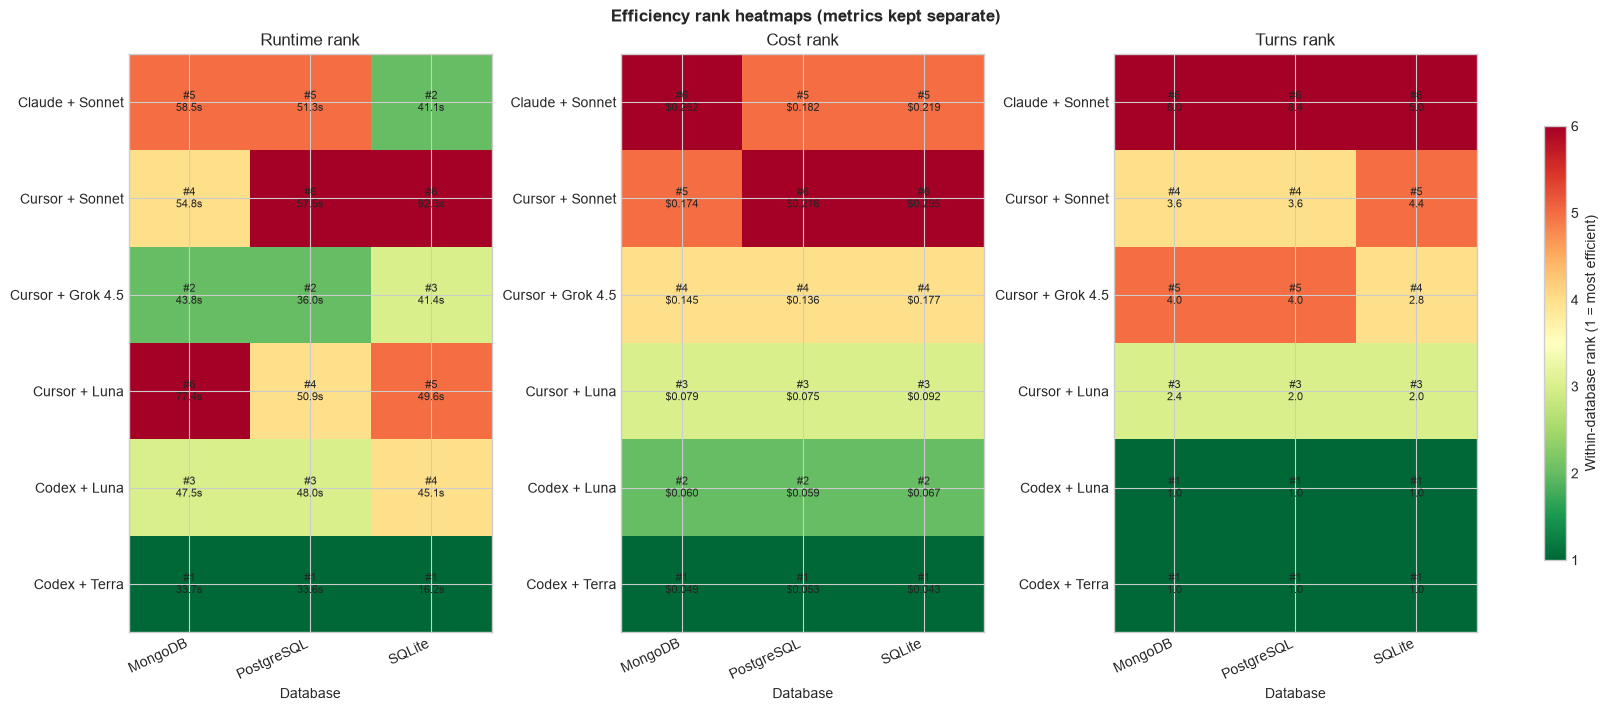

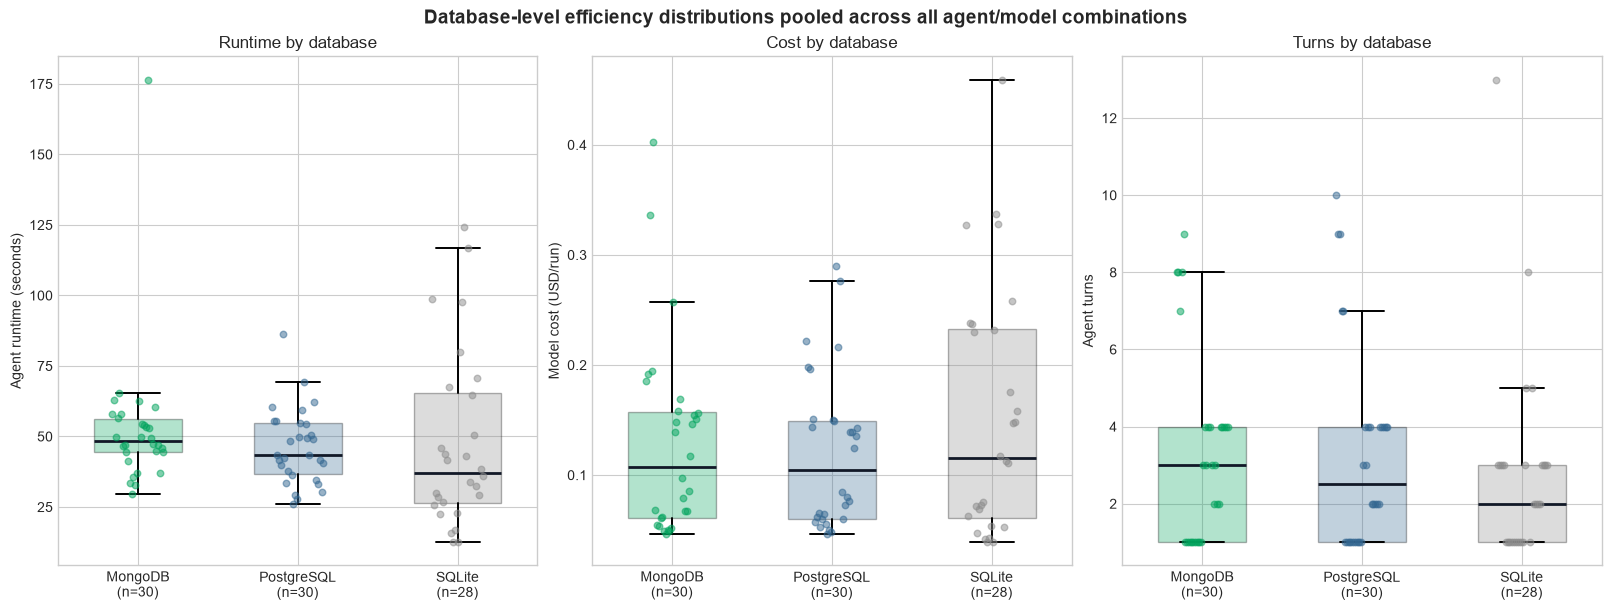

In [8]:
if not READY or summary.empty:
    print("Waiting for measurements.")
else:
    present_extensions = [name for name in EXTENSION_ORDER if name in set(runs["extension"])]
    extension_labels = [DISPLAY_NAMES.get(name, name) for name in present_extensions]
    y_positions = np.arange(len(present_extensions))

    # 1) Cost dot-and-whisker: individual attempts plus median and IQR.
    fig, axes = plt.subplots(1, 3, figsize=(17, 6), sharey=True, constrained_layout=True)
    for ax, database in zip(axes, DATABASE_ORDER):
        database_runs = runs[runs["database"] == database]
        for y_position, extension in zip(y_positions, present_extensions):
            subset = database_runs[database_runs["extension"] == extension].sort_values("repeat_idx")
            values = subset["cost_usd"].dropna().to_numpy(dtype=float)
            if not len(values):
                continue
            median = float(np.median(values))
            q1, q3 = np.quantile(values, [0.25, 0.75])
            jitter = np.linspace(-0.10, 0.10, len(subset)) if len(subset) > 1 else np.array([0.0])
            passed = subset["both_tests_passed"].to_numpy(dtype=bool)

            ax.scatter(
                subset.loc[passed, "cost_usd"],
                y_position + jitter[passed],
                color=COLORS.get(extension, "#6B7280"),
                alpha=0.65,
                s=34,
                zorder=2,
            )
            if (~passed).any():
                ax.scatter(
                    subset.loc[~passed, "cost_usd"],
                    y_position + jitter[~passed],
                    color="#DC2626",
                    marker="x",
                    linewidths=1.8,
                    s=52,
                    zorder=3,
                )
            ax.errorbar(
                median,
                y_position,
                xerr=np.array([[median - q1], [q3 - median]]),
                fmt="D",
                color="#111827",
                ecolor="#111827",
                capsize=4,
                markersize=5,
                zorder=4,
            )

        ax.set_title(f"{DISPLAY_NAMES[database]} (n={len(database_runs)})")
        ax.set_xlabel("Model cost (USD/run)")
        ax.set_yticks(y_positions, extension_labels)
        ax.invert_yaxis()
    axes[0].set_ylabel("Agent/model combo")
    fig.suptitle("Per-run cost: attempts, median, and interquartile range", fontweight="bold")
    plt.show()

    # 2) Runtime distribution: boxes show quartiles; dots preserve all n=3–5 runs.
    fig, axes = plt.subplots(1, 3, figsize=(17, 6), sharey=True, constrained_layout=True)
    for ax, database in zip(axes, DATABASE_ORDER):
        database_runs = runs[runs["database"] == database]
        distributions = []
        positions = []
        for y_position, extension in zip(y_positions, present_extensions):
            subset = database_runs[database_runs["extension"] == extension].sort_values("repeat_idx")
            values = subset["runtime_s"].dropna().to_numpy(dtype=float)
            if not len(values):
                continue
            distributions.append(values)
            positions.append(y_position)
            jitter = np.linspace(-0.09, 0.09, len(values)) if len(values) > 1 else np.array([0.0])
            ax.scatter(
                values,
                y_position + jitter,
                color=COLORS.get(extension, "#6B7280"),
                alpha=0.65,
                s=30,
                zorder=3,
            )
        if distributions:
            boxes = ax.boxplot(
                distributions,
                positions=positions,
                vert=False,
                widths=0.48,
                patch_artist=True,
                showfliers=False,
                medianprops={"color": "#111827", "linewidth": 1.8},
            )
            for patch, position in zip(boxes["boxes"], positions):
                extension = present_extensions[position]
                patch.set_facecolor(COLORS.get(extension, "#9CA3AF"))
                patch.set_alpha(0.22)
        ax.set_title(f"{DISPLAY_NAMES[database]} (n={len(database_runs)})")
        ax.set_xlabel("Agent runtime (seconds)")
        ax.set_yticks(y_positions, extension_labels)
        ax.invert_yaxis()
    axes[0].set_ylabel("Agent/model combo")
    fig.suptitle("Runtime distributions by database and agent/model", fontweight="bold")
    plt.show()

    # 3) Separate rank heatmaps avoid arbitrary weighting across unlike units.
    rank_metrics = [
        ("runtime_mean_s", "Runtime rank", "s"),
        ("cost_mean_usd", "Cost rank", "$"),
        ("turns_mean", "Turns rank", " turns"),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(16, 7), constrained_layout=True)
    for ax, (metric, title, unit) in zip(axes, rank_metrics):
        ranked = summary[["extension", "database", metric]].copy()
        ranked["rank"] = ranked.groupby("database", observed=True)[metric].rank(method="min", ascending=True)
        value_pivot = ranked.pivot(index="extension", columns="database", values=metric).reindex(
            index=present_extensions, columns=DATABASE_ORDER
        )
        rank_pivot = ranked.pivot(index="extension", columns="database", values="rank").reindex(
            index=present_extensions, columns=DATABASE_ORDER
        )
        image = ax.imshow(
            rank_pivot.to_numpy(dtype=float),
            cmap="RdYlGn_r",
            vmin=1,
            vmax=len(present_extensions),
            aspect="auto",
        )
        for row_index, extension in enumerate(present_extensions):
            for column_index, database in enumerate(DATABASE_ORDER):
                rank = rank_pivot.loc[extension, database]
                value = value_pivot.loc[extension, database]
                if pd.isna(rank) or pd.isna(value):
                    annotation = "—"
                elif unit == "$":
                    annotation = f"#{int(rank)}\n${value:.3f}"
                elif unit == "s":
                    annotation = f"#{int(rank)}\n{value:.1f}s"
                else:
                    annotation = f"#{int(rank)}\n{value:.1f}"
                ax.text(column_index, row_index, annotation, ha="center", va="center", fontsize=8)
        ax.set_title(title)
        ax.set_xticks(np.arange(len(DATABASE_ORDER)), [DISPLAY_NAMES[name] for name in DATABASE_ORDER], rotation=25, ha="right")
        ax.set_yticks(np.arange(len(present_extensions)), extension_labels)
        ax.set_xlabel("Database")
    fig.colorbar(image, ax=axes, label="Within-database rank (1 = most efficient)", shrink=0.75)
    fig.suptitle("Efficiency rank heatmaps (metrics kept separate)", fontweight="bold")
    plt.show()

    # 4) Pool all agent/model combinations to compare database-level distributions.
    pooled_metrics = [
        ("runtime_s", "Agent runtime (seconds)", "Runtime by database"),
        ("cost_usd", "Model cost (USD/run)", "Cost by database"),
        ("num_turns", "Agent turns", "Turns by database"),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(16, 6), constrained_layout=True)
    database_positions = np.arange(1, len(DATABASE_ORDER) + 1)
    for ax, (metric, y_label, title) in zip(axes, pooled_metrics):
        distributions = [
            runs.loc[runs["database"] == database, metric].dropna().to_numpy(dtype=float)
            for database in DATABASE_ORDER
        ]
        boxes = ax.boxplot(
            distributions,
            positions=database_positions,
            widths=0.55,
            patch_artist=True,
            showfliers=False,
            medianprops={"color": "#111827", "linewidth": 2},
            whiskerprops={"linewidth": 1.4},
            capprops={"linewidth": 1.4},
        )
        for patch, database in zip(boxes["boxes"], DATABASE_ORDER):
            patch.set_facecolor(COLORS[database])
            patch.set_alpha(0.30)
        for position, database, values in zip(database_positions, DATABASE_ORDER, distributions):
            jitter = np.linspace(-0.16, 0.16, len(values)) if len(values) > 1 else np.array([0.0])
            ax.scatter(
                position + jitter,
                values,
                color=COLORS[database],
                alpha=0.50,
                s=22,
                zorder=3,
            )
        labels = [
            f"{DISPLAY_NAMES[database]}\n(n={len(values)})"
            for database, values in zip(DATABASE_ORDER, distributions)
        ]
        ax.set_xticks(database_positions, labels)
        ax.set_ylabel(y_label)
        ax.set_title(title)
    fig.suptitle(
        "Database-level efficiency distributions pooled across all agent/model combinations",
        fontsize=14,
        fontweight="bold",
    )
    plt.show()

## Variant pruning: same model across harnesses

The design's prune rule: if a **model behaves the same across harnesses**, drop
one combo before scale. The two overlapping models in this matrix are:

- Sonnet 5: Claude Code vs Cursor
- GPT-5.6 Luna: Codex vs Cursor

"Same" here is operational, not statistical proof. With n=5, Wilson intervals
are wide. Treat a pair as **prunable** when pass rates overlap, cost/runtime
are the same order of magnitude, and the Mongo vs Postgres vs SQLite *pattern*
matches (not just the average). Keep both if one harness fails a database the
other consistently provisions, or if cost differs enough to change a Pareto
read.

Cursor + Grok and Codex + Terra have no same-model pair; they stay unless this
n=5 shows they add no extra ranking information.


In [9]:
if not READY:
    print("Waiting for measurements.")
else:
    rows = []
    for left, right, label in HARNESS_PAIRS:
        for database in DATABASE_ORDER:
            a = summary[(summary["extension"] == left) & (summary["database"] == database)]
            b = summary[(summary["extension"] == right) & (summary["database"] == database)]
            if a.empty or b.empty:
                rows.append(
                    {
                        "pair": label,
                        "database": DISPLAY_NAMES[database],
                        "note": "missing cell",
                    }
                )
                continue
            a, b = a.iloc[0], b.iloc[0]
            overlap = a.pass_rate_hi >= b.pass_rate_lo and b.pass_rate_hi >= a.pass_rate_lo
            rows.append(
                {
                    "pair": label,
                    "database": DISPLAY_NAMES[database],
                    "left": DISPLAY_NAMES[left],
                    "right": DISPLAY_NAMES[right],
                    "left_n": int(a.runs),
                    "right_n": int(b.runs),
                    "left_pass_pct": a.pass_rate_pct,
                    "right_pass_pct": b.pass_rate_pct,
                    "ci_overlap": overlap,
                    "pass_pp_diff": (a.pass_rate - b.pass_rate) * 100,
                    "runtime_ratio": a.runtime_mean_s / b.runtime_mean_s if b.runtime_mean_s else np.nan,
                    "cost_ratio": a.cost_mean_usd / b.cost_mean_usd if b.cost_mean_usd else np.nan,
                    "left_cost": a.cost_mean_usd,
                    "right_cost": b.cost_mean_usd,
                }
            )
    prune = pd.DataFrame(rows)
    display(prune.round(3))

    print("Pair-level prune hint (overlapping CIs are necessary, not proof of equivalence):")
    for left, right, label in HARNESS_PAIRS:
        subset = prune[prune["pair"] == label]
        if subset.empty or "ci_overlap" not in subset:
            print(f"- {label}: not enough cells")
            continue

        complete_cells = (subset[["left_n", "right_n"]] >= 5).all().all()
        close_completion = subset["pass_pp_diff"].abs().le(10).all()
        comparable_cost = subset["cost_ratio"].between(0.5, 2.0).all()
        prune_supported = (
            complete_cells
            and subset["ci_overlap"].all()
            and close_completion
            and comparable_cost
        )

        if prune_supported:
            cheaper = left if subset["left_cost"].mean() <= subset["right_cost"].mean() else right
            drop = right if cheaper == left else left
            print(
                f"- {label}: provisional prune candidate; completion differs by no more "
                f"than 10pp in each database. Keep {DISPLAY_NAMES[cheaper]} and "
                f"consider dropping {DISPLAY_NAMES[drop]}."
            )
        else:
            reasons = []
            if not complete_cells:
                reasons.append("one or more cells have fewer than five measured runs")
            if not close_completion:
                reasons.append("completion differs by more than 10pp")
            if not comparable_cost:
                reasons.append("mean cost differs by more than 2x")
            print(
                f"- {label}: do not prune from n=5 alone (" + "; ".join(reasons) + ")."
            )


,pair,database,left,right,left_n,right_n,left_pass_pct,right_pass_pct,ci_overlap,pass_pp_diff,runtime_ratio,cost_ratio,left_cost,right_cost
0,Sonnet across Claude vs Cursor,MongoDB,Claude + Sonnet,Cursor + Sonnet,5,5,100.0,100.0,True,0.0,1.068,1.503,0.262,0.174
1,Sonnet across Claude vs Cursor,PostgreSQL,Claude + Sonnet,Cursor + Sonnet,5,5,80.0,100.0,True,-20.0,0.892,0.842,0.182,0.216
2,Sonnet across Claude vs Cursor,SQLite,Claude + Sonnet,Cursor + Sonnet,5,5,100.0,80.0,True,20.0,0.446,0.743,0.219,0.295
3,Luna across Codex vs Cursor,MongoDB,Codex + Luna,Cursor + Luna,5,5,100.0,100.0,True,0.0,0.613,0.758,0.060,0.079
4,Luna across Codex vs Cursor,PostgreSQL,Codex + Luna,Cursor + Luna,5,5,100.0,80.0,True,20.0,0.942,0.796,0.059,0.075
5,Luna across Codex vs Cursor,SQLite,Codex + Luna,Cursor + Luna,5,3,100.0,100.0,True,0.0,0.909,0.731,0.067,0.092


Pair-level prune hint (overlapping CIs are necessary, not proof of equivalence):
- Sonnet across Claude vs Cursor: do not prune from n=5 alone (completion differs by more than 10pp).
- Luna across Codex vs Cursor: do not prune from n=5 alone (one or more cells have fewer than five measured runs; completion differs by more than 10pp).


## Sample size for the scale run

n=5 is for pruning, not ranking. Scale needs enough repeats to tell MongoDB
from PostgreSQL on **completion** and to put a usable interval on **cost/time**.

Rules of thumb used below (95% CI, 80% power where noted):

- Single-cell pass-rate CI half-width ≈ 1.96 √(p(1-p)/n). At p=0.8, n=10 → ±25pp,
  n=20 → ±18pp, n=30 → ±14pp. n=10 cannot distinguish 70% from 90% in one cell.
- Two-proportion n per group to detect a 20pp gap (0.70 vs 0.90) is about 30.
  A 10pp gap needs ~n=120 and is not worth buying at this task's cost.

Recommendation to compute from *this* run's observed pass rates: use n=**20**
if Mongo vs Postgres still looks close after pruning; n=**10** is enough only
if one database is already near-ceiling and the question is efficiency among
successes. n=30 is the upper end if we also want method-mix counts (Docker vs
apt) rather than just pass/fail.


In [10]:
def n_for_margin(p, margin, z=1.96):
    if margin <= 0:
        return np.inf
    return int(np.ceil((z**2 * p * (1 - p)) / margin**2))


def n_two_proportion(p1, p2, z_alpha=1.96, z_power=0.8416):
    delta = abs(p1 - p2)
    if delta == 0:
        return np.inf
    return int(
        np.ceil(
            ((z_alpha + z_power) ** 2 * (p1 * (1 - p1) + p2 * (1 - p2))) / delta**2
        )
    )


if not READY:
    print("Waiting for measurements. Sample-size table will use observed pass rates.")
    p_hat = 0.8
else:
    p_hat = float(runs["both_tests_passed"].mean())
    print(f"Observed overall pass rate on finished runs: {p_hat:.1%}")

ci_width = pd.DataFrame(
    {
        "n_per_variant": [10, 20, 30],
        "ci_halfwidth_pp_at_observed_p": [
            196 * np.sqrt(p_hat * (1 - p_hat) / n) for n in (10, 20, 30)
        ],
    }
)
power = pd.DataFrame(
    [
        {"contrast": "70% vs 90% (20pp)", "n_per_group": n_two_proportion(0.70, 0.90)},
        {"contrast": "80% vs 90% (10pp)", "n_per_group": n_two_proportion(0.80, 0.90)},
        {"contrast": "60% vs 90% (30pp)", "n_per_group": n_two_proportion(0.60, 0.90)},
        {"contrast": "CI ±10pp at p=0.8", "n_per_group": n_for_margin(0.8, 0.10)},
        {"contrast": "CI ±15pp at p=0.8", "n_per_group": n_for_margin(0.8, 0.15)},
    ]
)
display(ci_width.round(1))
display(power)
print(
    "Suggested scale N: 20/variant after pruning, or 10/variant if this n=5 "
    "already shows a large Mongo-vs-Postgres gap and we mainly want tighter cost CIs."
)


Observed overall pass rate on finished runs: 95.5%


,n_per_variant,ci_halfwidth_pp_at_observed_p
0,10,12.9
1,20,9.1
2,30,7.5


,contrast,n_per_group
0,70% vs 90% (20pp),59
1,80% vs 90% (10pp),197
2,60% vs 90% (30pp),29
3,CI ±10pp at p=0.8,62
4,CI ±15pp at p=0.8,28


Suggested scale N: 20/variant after pruning, or 10/variant if this n=5 already shows a large Mongo-vs-Postgres gap and we mainly want tighter cost CIs.


## Cost of this run and scale estimates

Scale cost ≈ (mean USD per finished run in the kept extensions) × variants × n.
Starved/harness failures are excluded from the mean so we do not treat missing
rows as free. Add ~15% contingency for retries.


In [11]:
if not READY:
    print("Waiting for measurements.")
else:
    cost_by_extension = (
        runs.groupby("extension", observed=True)
        .agg(
            n=("run_id", "size"),
            cost_total=("cost_usd", "sum"),
            cost_mean=("cost_usd", "mean"),
            runtime_mean_s=("runtime_s", "mean"),
        )
        .reindex([name for name in EXTENSION_ORDER if name in set(runs["extension"])])
        .reset_index()
    )
    cost_by_extension["label"] = cost_by_extension["extension"].map(DISPLAY_NAMES)
    display(cost_by_extension.round(3))

    this_run_cost = float(runs["cost_usd"].sum())
    mean_all = float(runs["cost_usd"].mean())
    print(f"This request, finished runs only: ${this_run_cost:.2f} across {len(runs)} rows")
    print(f"Mean $/run: ${mean_all:.3f}")

    keep_all = EXTENSION_ORDER
    drop_cursor_sonnet = [e for e in EXTENSION_ORDER if e != "cursor-sonnet"]
    drop_cursor_luna = [e for e in EXTENSION_ORDER if e != "cursor-luna"]
    drop_both_dupes = [e for e in EXTENSION_ORDER if e not in {"cursor-sonnet", "cursor-luna"}]

    def scenario_cost(extensions, n, label):
        subset = runs[runs["extension"].isin(extensions)]
        if subset.empty:
            return None
        mean = float(subset["cost_usd"].mean())
        variants = len(extensions) * len(DATABASE_ORDER)
        trials = variants * n
        base = mean * trials
        return {
            "scenario": label,
            "extensions": len(extensions),
            "variants": variants,
            "n": n,
            "trials": trials,
            "mean_usd_per_run": mean,
            "estimated_usd": base,
            "with_15pct_contingency": base * 1.15,
        }

    scenarios = []
    for n in (10, 20, 30):
        scenarios.append(scenario_cost(keep_all, n, f"Keep all 6 combos, n={n}"))
        scenarios.append(scenario_cost(drop_cursor_sonnet, n, f"Drop Cursor+Sonnet, n={n}"))
        scenarios.append(scenario_cost(drop_cursor_luna, n, f"Drop Cursor+Luna, n={n}"))
        scenarios.append(scenario_cost(drop_both_dupes, n, f"Drop both duplicate-model harnesses, n={n}"))
    estimate = pd.DataFrame([row for row in scenarios if row])
    display(estimate.round(2))

    recommended = scenario_cost(drop_both_dupes, 20, "recommended")
    if recommended:
        print(
            "Working recommendation if both harness pairs look interchangeable: "
            f"4 combos × 3 DBs × n=20 = {recommended['trials']} trials, "
            f"about ${recommended['estimated_usd']:.0f} "
            f"(${recommended['with_15pct_contingency']:.0f} with contingency)."
        )


,extension,n,cost_total,cost_mean,runtime_mean_s,label
0,claude-sonnet,15,3.317,0.221,50.299,Claude + Sonnet
1,cursor-sonnet,15,3.428,0.229,68.174,Cursor + Sonnet
2,cursor-grok,15,2.293,0.153,40.416,Cursor + Grok 4.5
3,cursor-luna,13,1.046,0.080,60.797,Cursor + Luna
4,codex-luna,15,0.935,0.062,46.858,Codex + Luna
5,codex-terra,15,0.728,0.049,27.828,Codex + Terra


This request, finished runs only: $11.75 across 88 rows
Mean $/run: $0.133


,scenario,extensions,variants,n,trials,mean_usd_per_run,estimated_usd,with_15pct_contingency
0,"Keep all 6 combos, n=10",6,18,10,180,0.13,24.03,27.63
1,"Drop Cursor+Sonnet, n=10",5,15,10,150,0.11,17.09,19.66
2,"Drop Cursor+Luna, n=10",5,15,10,150,0.14,21.40,24.61
3,"Drop both duplicate-model harnesses, n=10",4,12,10,120,0.12,14.54,16.73
4,"Keep all 6 combos, n=20",6,18,20,360,0.13,48.05,55.26
5,"Drop Cursor+Sonnet, n=20",5,15,20,300,0.11,34.18,39.31
6,"Drop Cursor+Luna, n=20",5,15,20,300,0.14,42.80,49.22
7,"Drop both duplicate-model harnesses, n=20",4,12,20,240,0.12,29.09,33.45
8,"Keep all 6 combos, n=30",6,18,30,540,0.13,72.08,82.89
9,"Drop Cursor+Sonnet, n=30",5,15,30,450,0.11,51.28,58.97


Working recommendation if both harness pairs look interchangeable: 4 combos × 3 DBs × n=20 = 240 trials, about $29 ($33 with contingency).


## Interpretation

The request terminated **errored** with 88/90 measurement rows. Both missing
rows were Cursor + Luna / SQLite runs that starved after 15 minutes; this cell
has only n=3, all passing. Treat starvation as harness reliability, not SQLite
failure, but do not call Cursor + Luna equivalent to Codex + Luna from this run.

Among measured runs, 84/88 passed both tests (172/176 individual tests). The
four failures were:

- `connection-verified-in-agent`: one Claude/PostgreSQL, one Cursor+Luna/PostgreSQL,
  and one Cursor+Grok/PostgreSQL run
- `uri-reported`: one Cursor+Sonnet/SQLite run

The observed total was **$11.75** for 88 measured runs (mean **$0.133/run**).

### Pruning decision

Do **not** prune either same-model harness pair from n=5 alone:

- Sonnet differs by 20 percentage points on PostgreSQL and SQLite, in opposite
  directions. Wide intervals overlap, but overlap is not evidence of equivalence.
- Luna differs by 20 points on PostgreSQL, and Cursor+Luna/SQLite is incomplete
  because two of five runs starved.

If budget requires pruning before another pilot, keeping Claude+Sonnet and
Codex+Luna is the lower-risk operational choice because those harnesses completed
all cells. It should be labeled a budget/reliability choice, not a finding that
the dropped harnesses behave identically.

### Scale recommendation

Use at least **n=20 per retained variant** for the next completion-rate analysis.
n=10 is adequate only for large differences or efficiency summaries; at p≈0.8
its approximate 95% interval is still ±25 percentage points. n=30 is preferable
if provisioning-method frequencies are a primary output.

This run is `docker-host` only. A stock arm is a separate matrix and cost if the
environment comparison remains in scope.
